In [21]:
import baltic as bt
import pandas as pd
import numpy as np

from collections import defaultdict
from collections import Counter
import itertools


import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
import matplotlib.ticker as ticker

import re
import random
from scipy.stats import norm


In [3]:
tree_folder = "host_trees"
clades = ['NA-avian', 'swine', 'human', 'canine', 'equine']

In [5]:
host_trees = {}

for clade in clades:
    
    tree = bt.loadNewick(f"{tree_folder}/{clade}.nwk", absoluteTime= False)
    
    host_trees[f"{clade}"] = tree
    

In [6]:
host_trees

{'NA-avian': <baltic.baltic.tree at 0x106203fd0>,
 'swine': <baltic.baltic.tree at 0x30f7d7f70>,
 'human': <baltic.baltic.tree at 0x30fb67160>,
 'canine': <baltic.baltic.tree at 0x30fc98a90>,
 'equine': <baltic.baltic.tree at 0x30fd3aaa0>}

In [8]:
reassortment_count = {}
gene_segment_counts = {name: {} for name in host_trees.keys()}
num_segment_counts = {name: {} for name in host_trees.keys()}
leaf_list = {name: [] for name in host_trees.keys()}
nodes = {}
leaves = {}

# dictionary for segment co-occurrences
segment_pair_counts = {name: defaultdict(lambda: defaultdict(int)) for name in host_trees.keys()}

gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for name, tree in host_trees.items():
    
    leaf = []
    node_count = 0
    leaf_count = 0
    count = 0
    tree_segment_counts = {segment: 0 for segment in gene_segments}
    num_segments_involved = {i: 0 for i in range(1, 8)}
    
    for k in tree.Objects:
        if k.traits.get('is_reassorted'):
            
            raw_segments = k.traits["rea"]
            is_uncertain = all([g_str.startswith('_') for g_str in raw_segments.split('-')])
            
            lst = [seg.split("(")[0].lstrip('_') for seg in raw_segments.split("-")]
            num_segments_involved[len(lst)] += 1
            count += 0.5 if is_uncertain else 1
            
            for seg in lst:
                tree_segment_counts[seg] += 0.5 if seg.startswith('_') else 1
                
            if k.is_node():
                node_count += 0.5 if is_uncertain else 1
            else:
                leaf_count += 0.5 if is_uncertain else 1
                leaf.append(k.name)
            
            # counting segment pairs (combinations of 2)
            if len(lst) > 1:
                for seg1, seg2 in combinations(lst, 2):
                    # increment both directions for easy access
                    segment_pair_counts[name][seg1][seg2] += 1
                    segment_pair_counts[name][seg2][seg1] += 1
    
    leaf_list[name] = leaf
    reassortment_count[name] = count
    nodes[name] = node_count
    leaves[name] = leaf_count
    gene_segment_counts[name] = tree_segment_counts
    num_segment_counts[name] = num_segments_involved

In [9]:
num_segment_counts

{'NA-avian': {1: 444, 2: 117, 3: 38, 4: 16, 5: 8, 6: 3, 7: 0},
 'swine': {1: 196, 2: 56, 3: 30, 4: 13, 5: 15, 6: 7, 7: 4},
 'human': {1: 5, 2: 0, 3: 2, 4: 0, 5: 1, 6: 2, 7: 0},
 'canine': {1: 6, 2: 1, 3: 1, 4: 0, 5: 0, 6: 0, 7: 0},
 'equine': {1: 4, 2: 1, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0}}

In [10]:
gene_segment_counts

{'NA-avian': {'NA': 173,
  'NP': 131,
  'NS': 100,
  'PB1': 111,
  'PB2': 117,
  'MP': 99,
  'PA': 183},
 'swine': {'NA': 59,
  'NP': 93,
  'NS': 93,
  'PB1': 63,
  'PB2': 81,
  'MP': 107,
  'PA': 99},
 'human': {'NA': 2, 'NP': 5, 'NS': 4, 'PB1': 3, 'PB2': 6, 'MP': 3, 'PA': 5},
 'canine': {'NA': 1, 'NP': 2, 'NS': 2, 'PB1': 2, 'PB2': 1, 'MP': 2, 'PA': 1},
 'equine': {'NA': 2, 'NP': 0, 'NS': 2, 'PB1': 1, 'PB2': 0, 'MP': 0, 'PA': 1}}

In [11]:
segment_pair_counts

{'NA-avian': defaultdict(<function __main__.<dictcomp>.<lambda>()>,
             {'NA': defaultdict(int,
                          {'PB1': 24,
                           'PA': 28,
                           'NP': 21,
                           'MP': 20,
                           'NS': 19,
                           'PB2': 19}),
              'PB1': defaultdict(int,
                          {'NA': 24,
                           'PA': 29,
                           'NP': 29,
                           'MP': 29,
                           'NS': 14,
                           'PB2': 26}),
              'PA': defaultdict(int,
                          {'NA': 28,
                           'PB1': 29,
                           'NP': 29,
                           'PB2': 21,
                           'NS': 19,
                           'MP': 20}),
              'NP': defaultdict(int,
                          {'NA': 21,
                           'PA': 29,
                           'PB1'

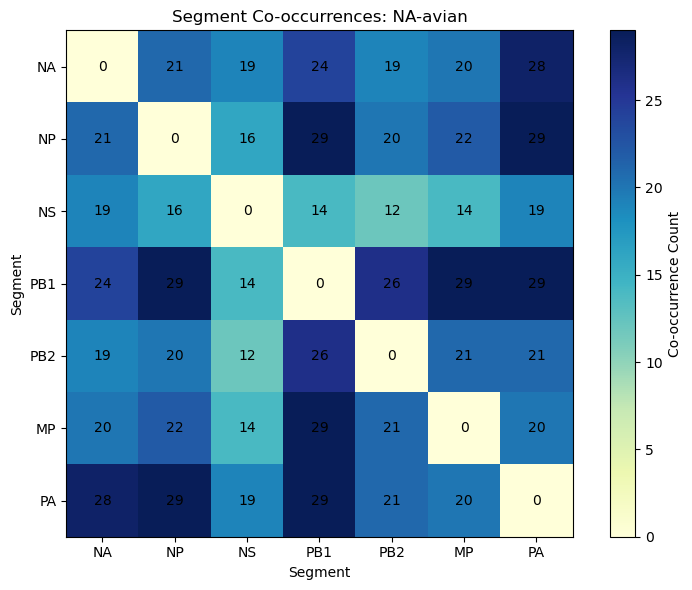

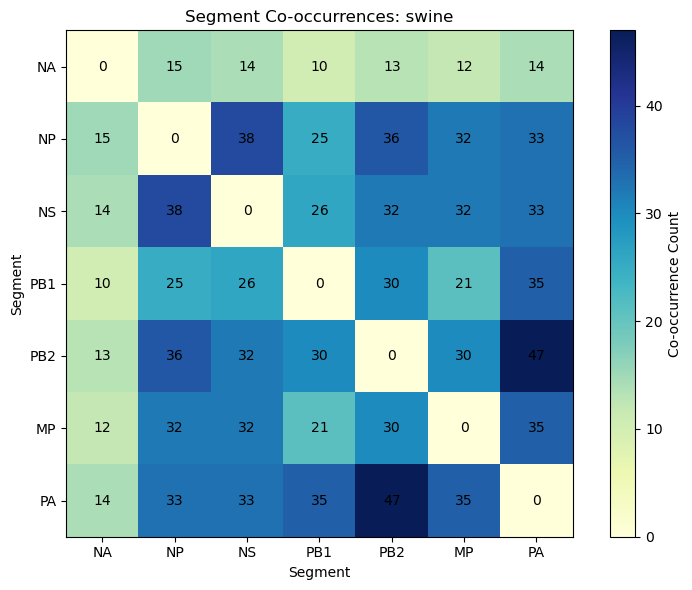

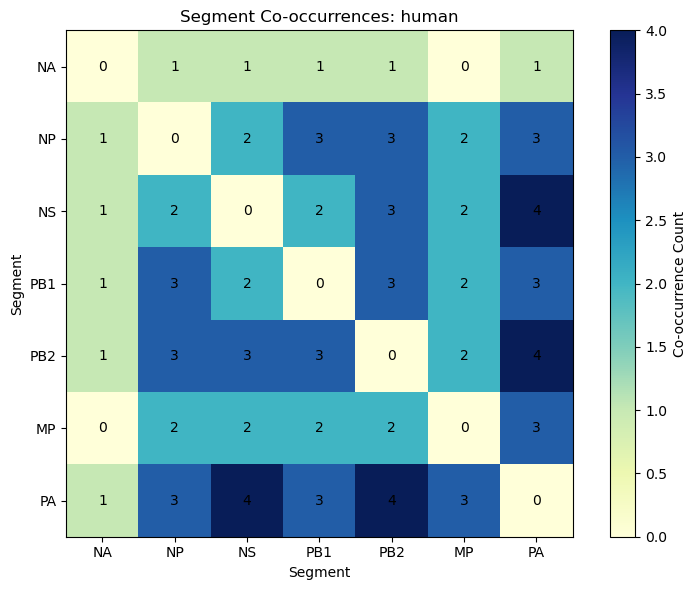

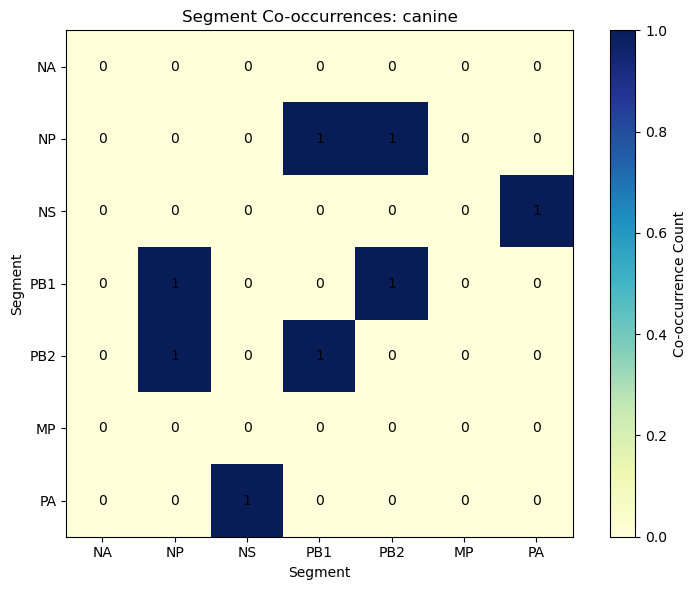

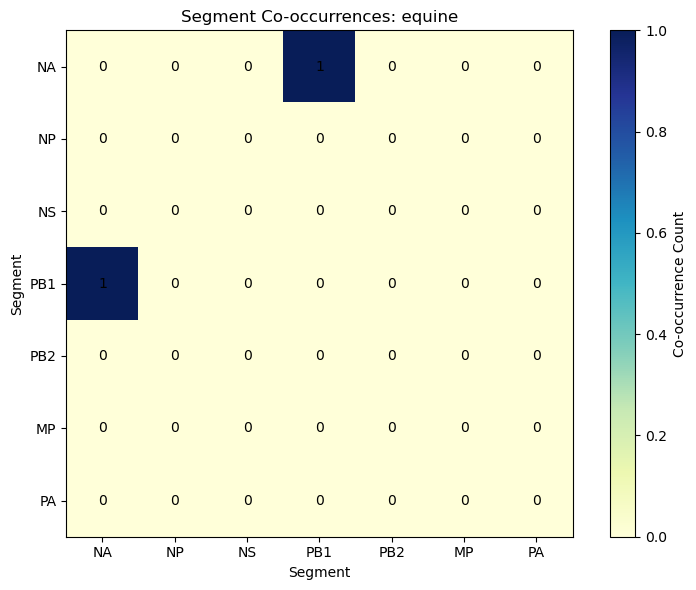

In [13]:
gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for host in host_trees.keys():
    
    # co-occurrence matrix
    co_matrix = np.zeros((len(gene_segments), len(gene_segments)), dtype=int)
    
    for i, seg1 in enumerate(gene_segments):
        for j, seg2 in enumerate(gene_segments):
            co_matrix[i, j] = segment_pair_counts[host][seg1].get(seg2, 0)
    
    plt.figure(figsize=(8,6))
    im = plt.imshow(co_matrix, cmap='YlGnBu')
    plt.colorbar(im, label='Co-occurrence Count')
    
    # Set axis labels
    plt.xticks(ticks=np.arange(len(gene_segments)), labels=gene_segments)
    plt.yticks(ticks=np.arange(len(gene_segments)), labels=gene_segments)
    
    # Annotate the cells with counts
    for i in range(len(gene_segments)):
        for j in range(len(gene_segments)):
            plt.text(j, i, co_matrix[i, j], ha='center', va='center', color='black')
    
    plt.title(f"Segment Co-occurrences: {host}")
    plt.xlabel("Segment")
    plt.ylabel("Segment")
    plt.tight_layout()
    plt.show()


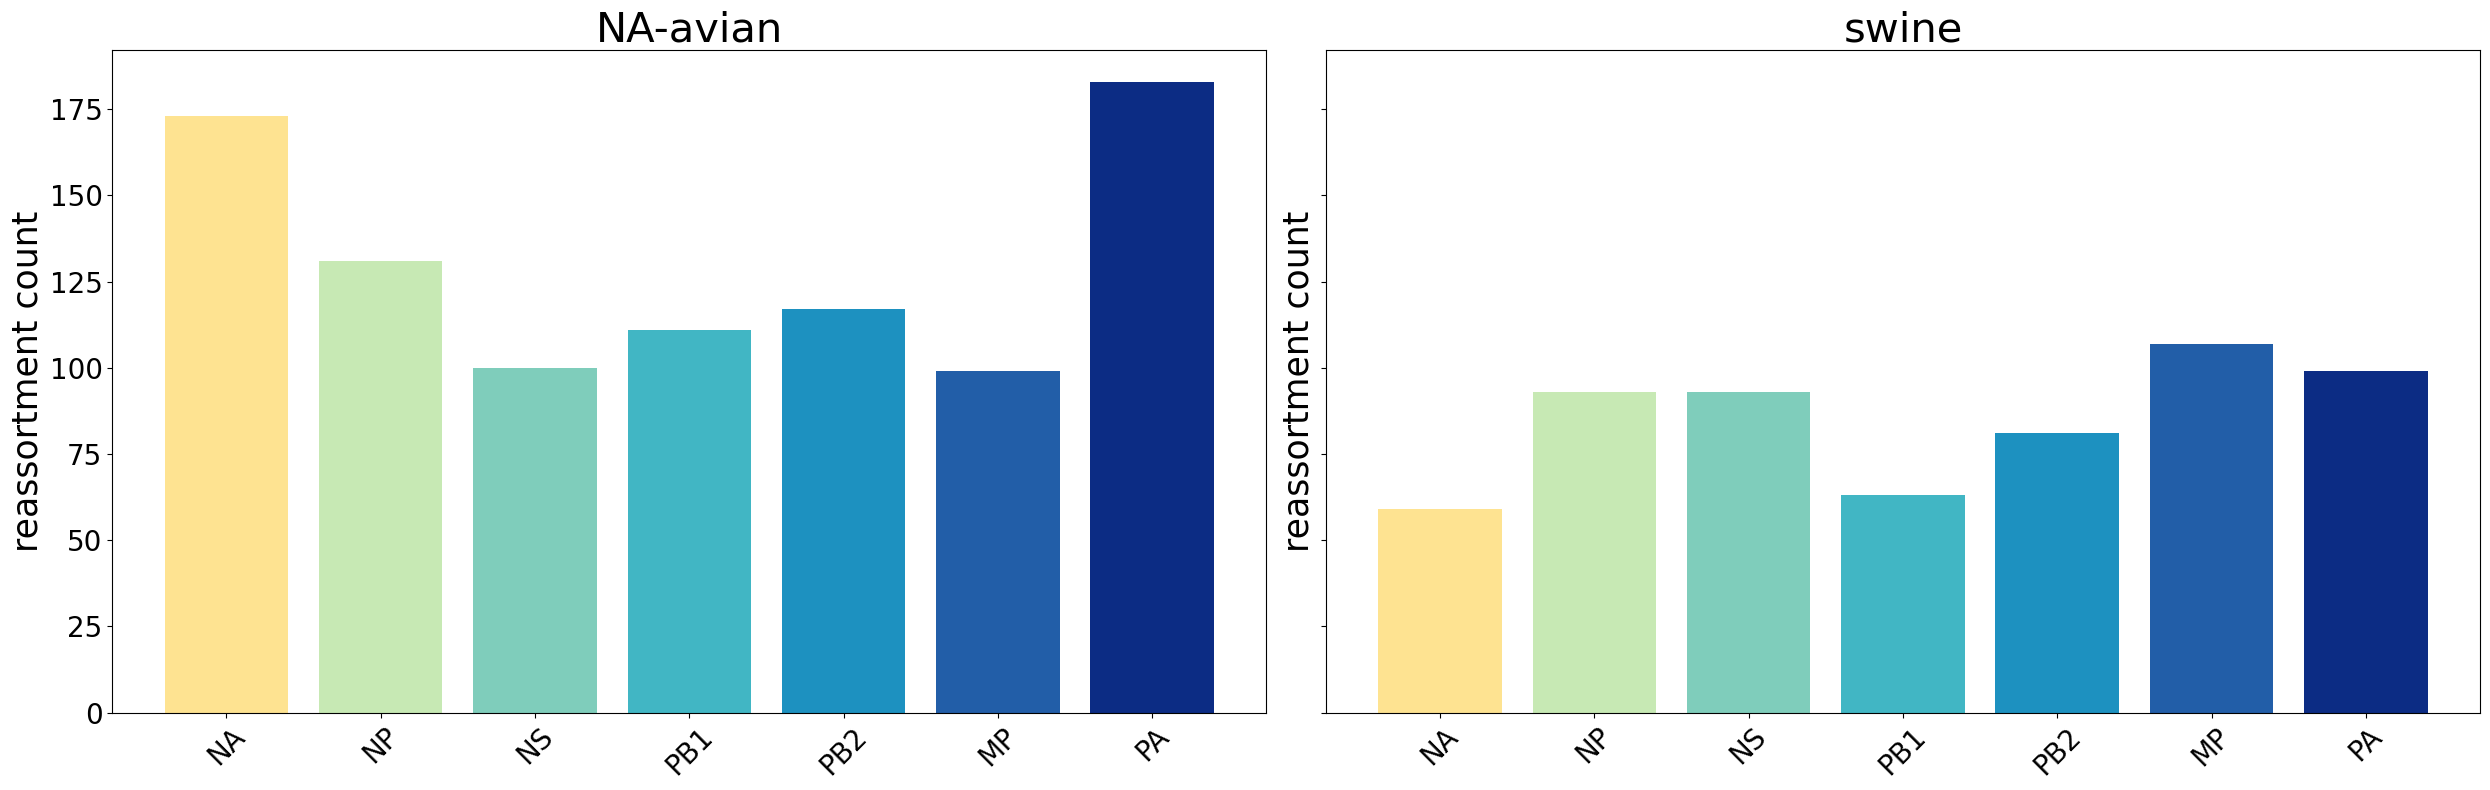

In [17]:
genes = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA'] 
colors = ['#fee391', '#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0', '#225ea8', '#0c2c84']

# filtering to only the NA-avian and swine trees
trees = [t for t in host_trees.keys() if t in ["NA-avian", "swine"]]

fig, axes = plt.subplots(nrows=1, ncols=len(trees), figsize=(25, 8), sharey=True)

for idx, tree_name in enumerate(trees):
    ax = axes[idx]
    
    values = [gene_segment_counts[tree_name][gene] for gene in genes]
    x = np.arange(len(genes))
    
    ax.bar(x, values, color=colors, width=0.8)
    
    ax.set_title(tree_name, fontsize=30)
    ax.set_xticks(x)
    ax.set_xticklabels(genes, rotation=45, fontsize=20)
    ax.set_ylabel('reassortment count', fontsize=25)
    ax.tick_params(axis='y', labelsize=20)

plt.tight_layout()
plt.show()


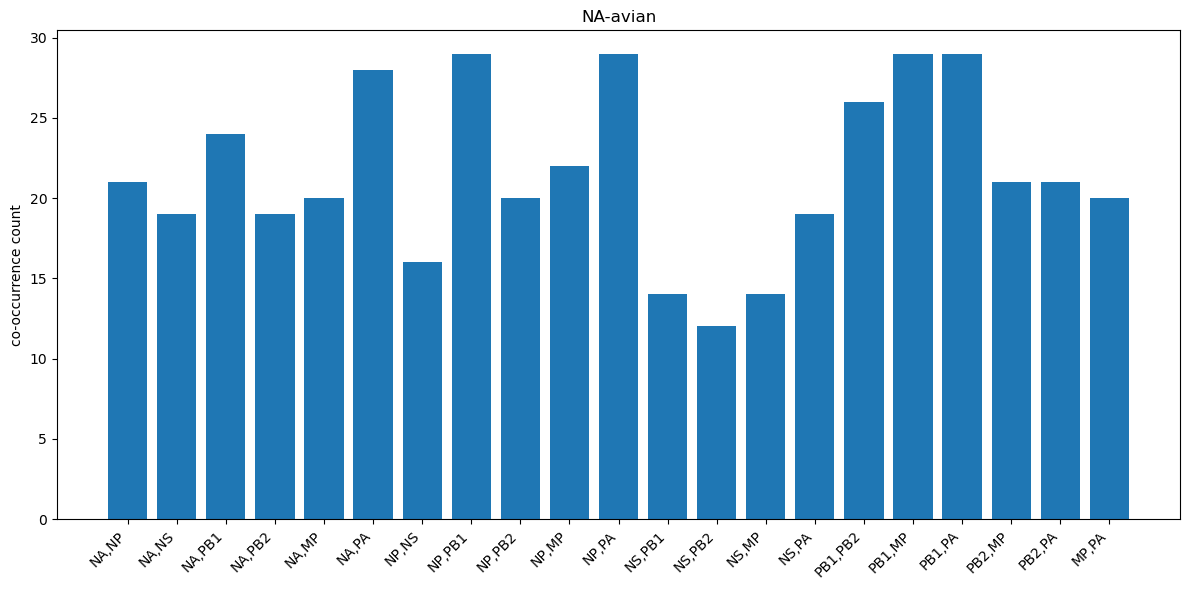

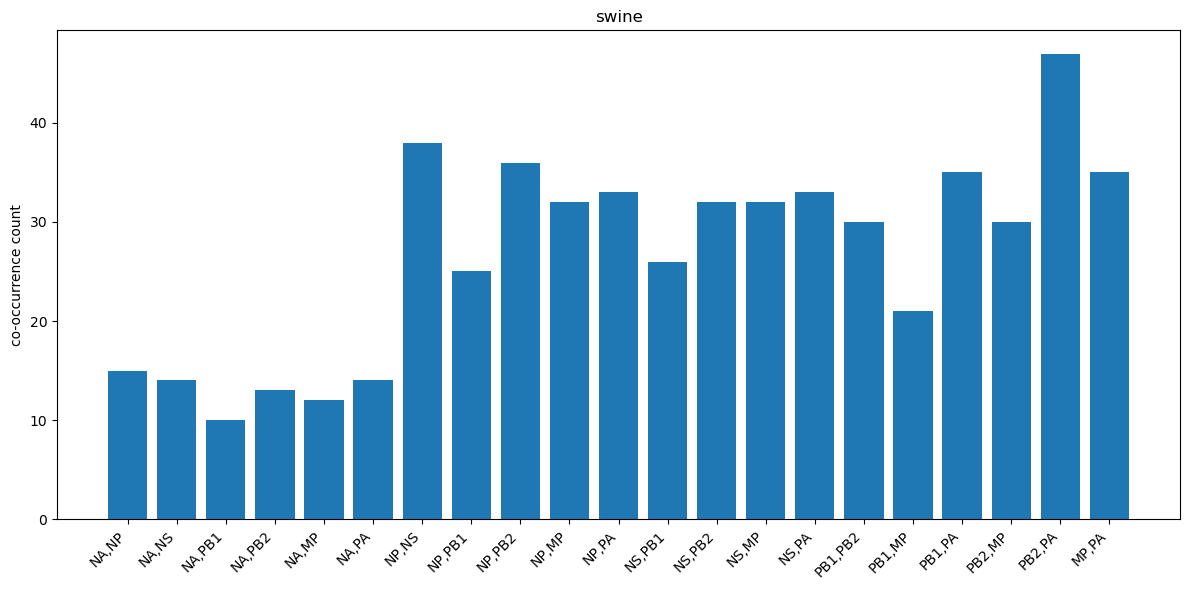

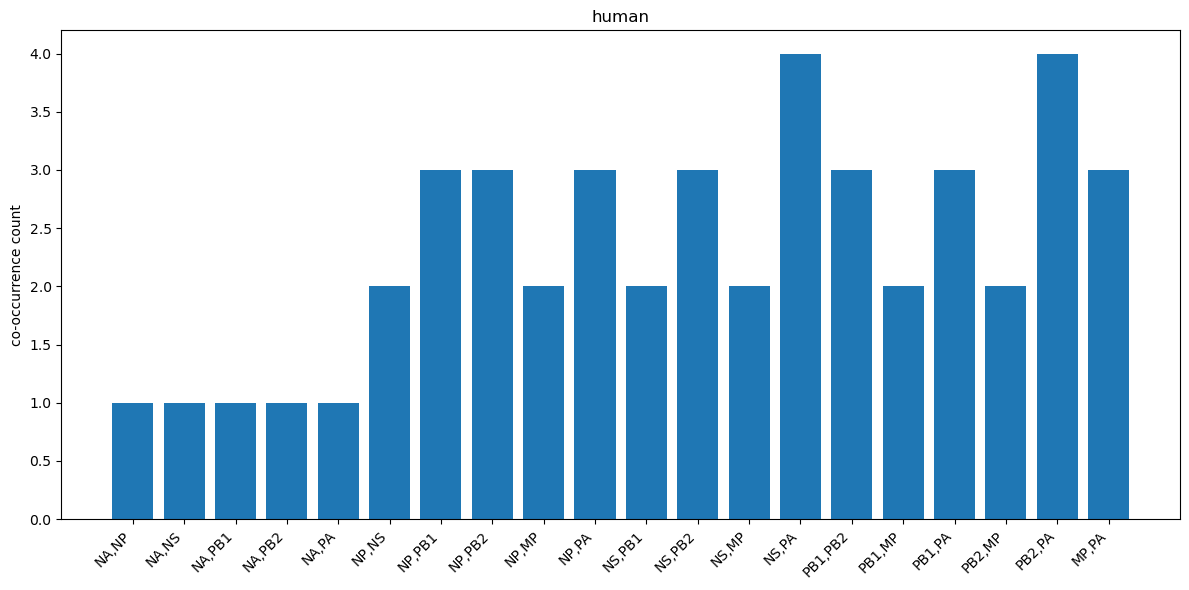

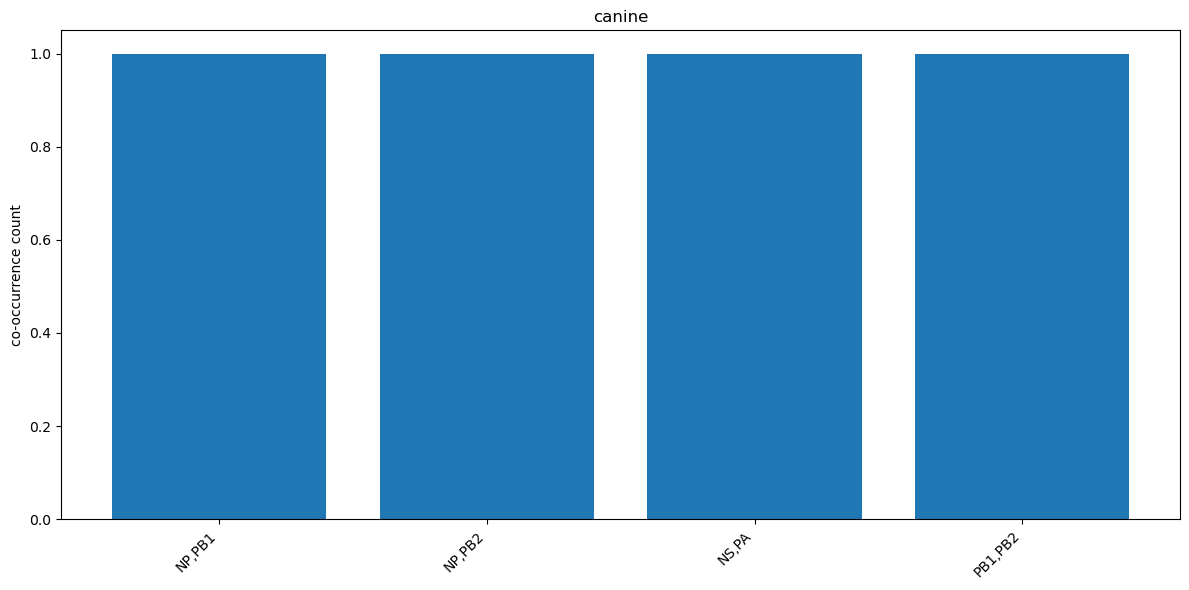

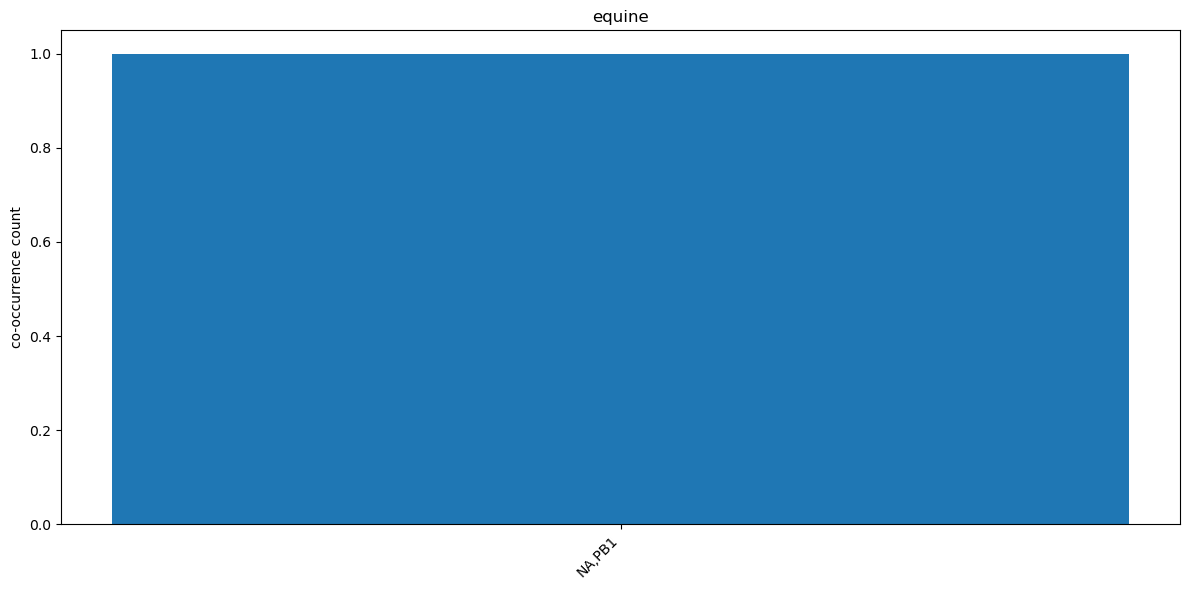

In [18]:
gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for host in host_trees.keys():
    pairs = []
    counts = []

    # flatten the segment_pair_counts into pairs and counts
    for i, seg1 in enumerate(gene_segments):
        for j, seg2 in enumerate(gene_segments):
            if i < j:  # only count each pair once
                count = segment_pair_counts[host][seg1].get(seg2, 0)
                if count > 0:
                    pairs.append(f"{seg1},{seg2}")
                    counts.append(count)
    
    # Create bar plot
    plt.figure(figsize=(12,6))
    plt.bar(pairs, counts)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("co-occurrence count")
    plt.title(host)
    plt.tight_layout()
    plt.show()


In [22]:
gene_segments = ['NA', 'NP', 'NS', 'PB1', 'PB2', 'MP', 'PA']

for host in host_trees.keys():
    missing_pairs = []

    # Loop over all unique pairs
    for seg1, seg2 in itertools.combinations(gene_segments, 2):
        count = segment_pair_counts[host][seg1].get(seg2, 0)
        if count == 0:
            missing_pairs.append(f"{seg1},{seg2}")
    
    print(f"Tree: {host}")
    print("Missing segment pairs:", missing_pairs)
    print()


Tree: NA-avian
Missing segment pairs: []

Tree: swine
Missing segment pairs: []

Tree: human
Missing segment pairs: ['NA,MP']

Tree: canine
Missing segment pairs: ['NA,NP', 'NA,NS', 'NA,PB1', 'NA,PB2', 'NA,MP', 'NA,PA', 'NP,NS', 'NP,MP', 'NP,PA', 'NS,PB1', 'NS,PB2', 'NS,MP', 'PB1,MP', 'PB1,PA', 'PB2,MP', 'PB2,PA', 'MP,PA']

Tree: equine
Missing segment pairs: ['NA,NP', 'NA,NS', 'NA,PB2', 'NA,MP', 'NA,PA', 'NP,NS', 'NP,PB1', 'NP,PB2', 'NP,MP', 'NP,PA', 'NS,PB1', 'NS,PB2', 'NS,MP', 'NS,PA', 'PB1,PB2', 'PB1,MP', 'PB1,PA', 'PB2,MP', 'PB2,PA', 'MP,PA']



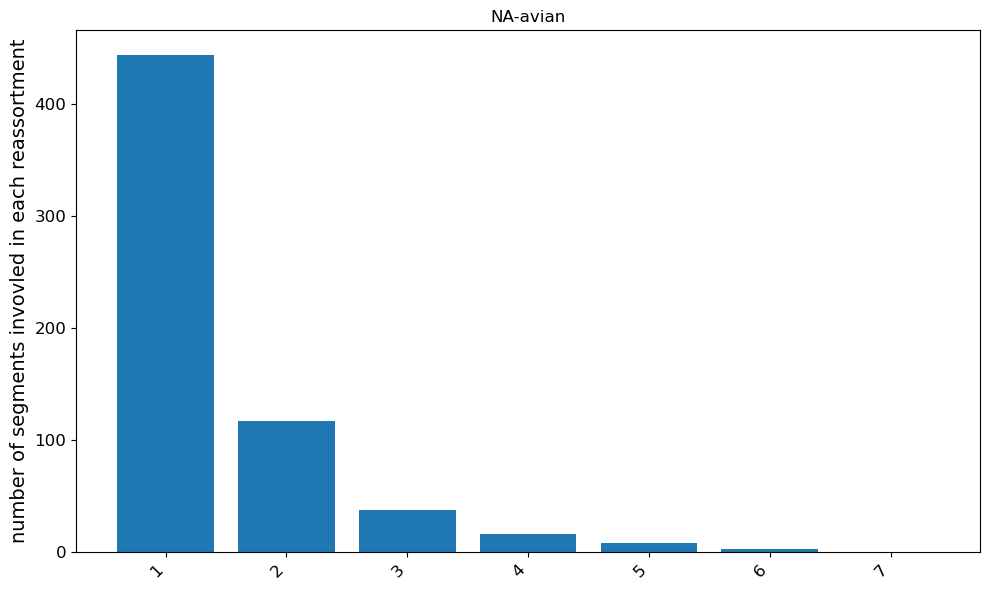

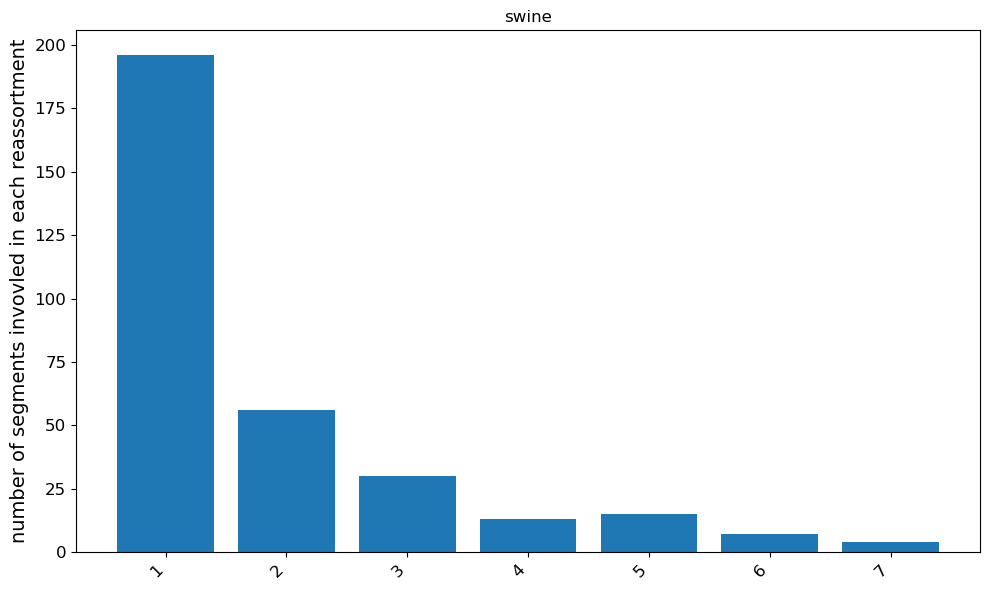

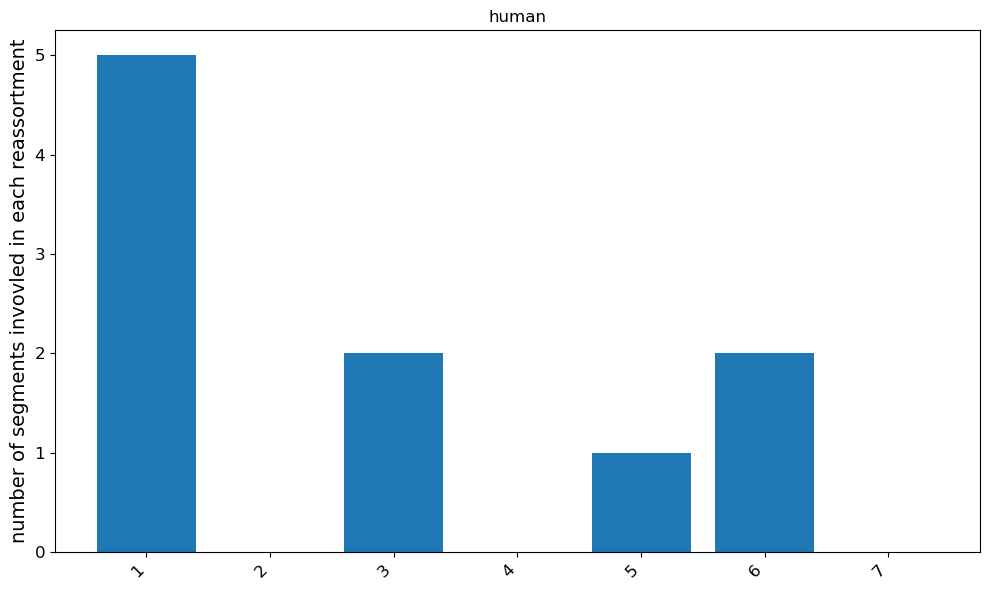

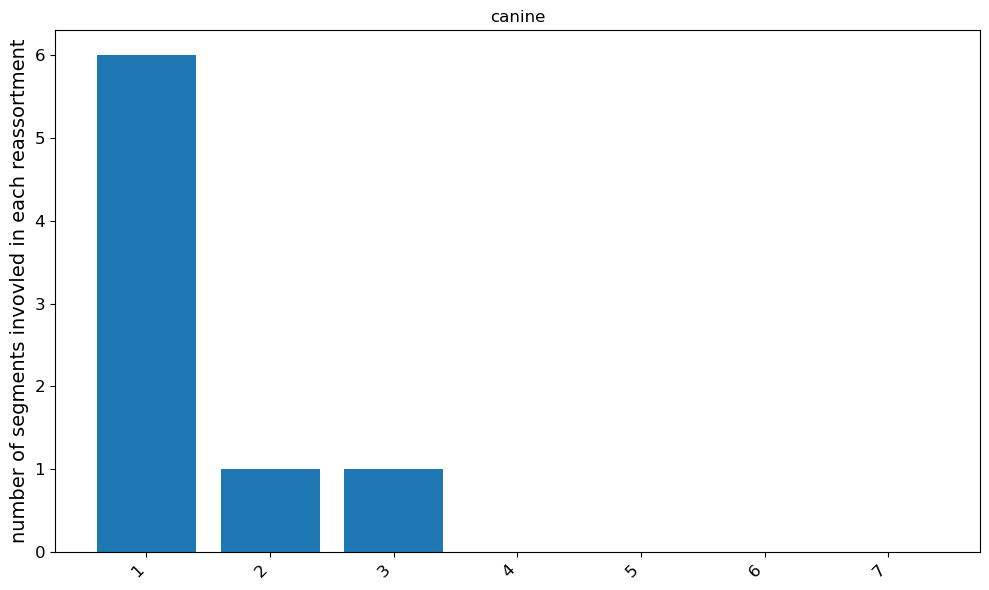

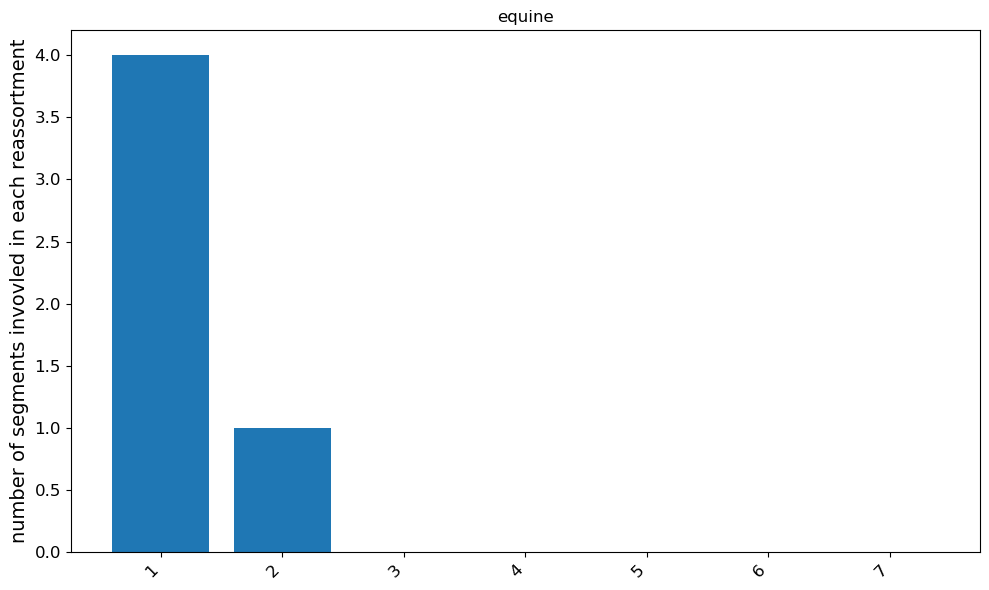

In [24]:
for host in host_trees.keys():
    
    counts = []
    labels = []

    for num_segments, count in num_segment_counts[host].items():
        counts.append(count)
        labels.append(num_segments)

    plt.figure(figsize=(10, 6))
    plt.bar(labels, counts)
    
    
    plt.title(f"{host}")
    plt.ylabel('number of segments invovled in each reassortment', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()